# Trader Behavior Analysis using Fear & Greed Index

## 1. Data Loading

In this section, we load the datasets required for analysis. 
The first dataset contains trading data, and the second dataset contains market sentiment (Fear & Greed index).

In [3]:
import pandas as pd

# load datasets from Downloads
sentiment = pd.read_csv("C:/Users/Danish Akbar/Downloads/fear_greed_index.csv")
trades = pd.read_csv("C:/Users/Danish Akbar/Downloads/historical_data.csv")

# preview
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Data Cleaning

Before analysis, I clean and prepare the data. 
This includes fixing date formats and simplifying sentiment labels for better analysis.

In [35]:
sentiment['classification'] = sentiment['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

I cleaned the data by standardizing date formats and simplifying sentiment labels. 
This ensures both datasets can be merged correctly and analyzed efficiently.

Now, I combine trading data with market sentiment using the date column.
This allows me to analyze how trader performance varies under different market emotions (Fear, Greed, Neutral).

In [38]:
print(trades['date'].min(), trades['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


In [39]:
sentiment_filtered = sentiment[
    (sentiment['date'] >= trades['date'].min()) &
    (sentiment['date'] <= trades['date'].max())
]

In [54]:
# Merge trading data with sentiment data on date
df = trades.merge(
    sentiment_filtered[['date', 'classification']],
    on='date',
    how='left'
)

In [55]:
df['classification'].isnull().sum()

df = df.dropna(subset=['classification'])

## Exploratory Data Analysis

In [45]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Greed


In [23]:
df = df.dropna(subset=['classification'])

In [24]:
df.groupby('classification')['Closed PnL'].mean()

classification
Fear       49.212077
Greed      53.882281
Neutral    34.307718
Name: Closed PnL, dtype: float64

In [26]:
df['classification'].value_counts()

classification
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64

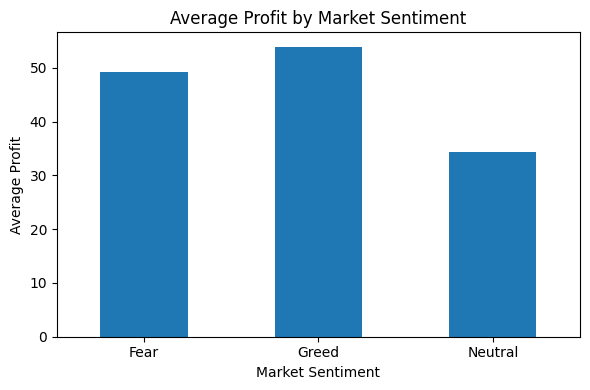

In [46]:
plt.figure(figsize=(6,4))

df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')

plt.title('Average Profit by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [47]:
df.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack()

Side,BUY,SELL
classification,,
Fear,56.015456,42.542558
Greed,18.882476,85.026753
Neutral,29.227429,39.456408


In [29]:
df.groupby(['classification', 'Side'])['Closed PnL'].sum()

classification  Side
Fear            BUY     2.308117e+06
                SELL    1.788149e+06
Greed           BUY     8.028073e+05
                SELL    4.062493e+06
Neutral         BUY     5.544151e+05
                SELL    7.385056e+05
Name: Closed PnL, dtype: float64

In [31]:
df['profit_flag'] = df['Closed PnL'] > 0

df.groupby('classification')['profit_flag'].mean()

classification
Fear       0.407871
Greed      0.420311
Neutral    0.396991
Name: profit_flag, dtype: float64

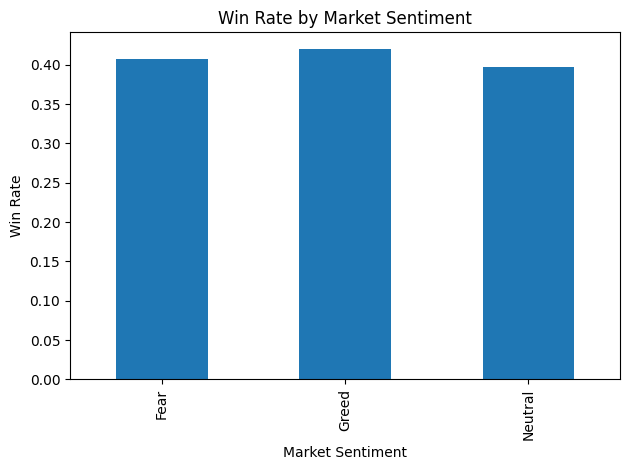

In [57]:
# Create profit flag again (important)
df['profit_flag'] = df['Closed PnL'] > 0

# Visualizing win rate across sentiments
df.groupby('classification')['profit_flag'].mean().plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.tight_layout()
plt.show()

In [58]:
print("Higher win rate observed during Greed market conditions")

Higher win rate observed during Greed market conditions


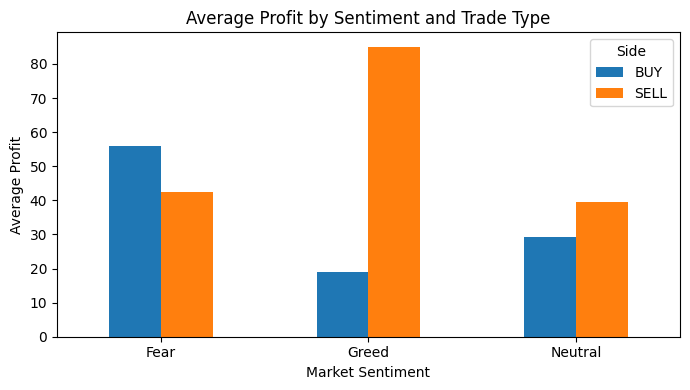

In [48]:
df.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack().plot(kind='bar', figsize=(7,4))

plt.title('Average Profit by Sentiment and Trade Type')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The analysis shows that trader profitability is influenced by both market sentiment and trade direction. During greed phases, traders achieve higher profits overall, especially in SELL positions, indicating potential profit taking behavior. In contrast, during fear periods, BUY trades perform relatively better, suggesting accumulation strategies. Win rates also vary across sentiment regimes, highlighting the impact of market psychology on trading outcomes.

In [50]:
df['profit_flag'] = df['Closed PnL'] > 0

In [53]:
summary = df.assign(
    profit_flag = df['Closed PnL'] > 0
).groupby('classification').agg({
    'Closed PnL': ['mean', 'sum'],
    'profit_flag': 'mean'
})

summary.columns = ['Avg Profit', 'Total Profit', 'Win Rate']

summary
summary.sort_values(by='Avg Profit', ascending=False)

,Avg Profit,Total Profit,Win Rate
classification,,,
Greed,53.882281,4.865301e+06,0.420311
Fear,49.212077,4.096266e+06,0.407871
Neutral,34.307718,1.292921e+06,0.396991
